# 🚗 Detección y Reconocimiento de Placas Vehiculares Colombianas

**Autor:** Juan Diego Chaparro García  
**Proyecto:** Sistema de visión artificial para la detección automática de placas colombianas  
**Tecnologías:** YOLOv11 · EasyOCR · Roboflow · Google Colab (GPU T4)

---

> 🇨🇴 **Contexto colombiano:** Las placas vehiculares en Colombia siguen el formato **ABC-123** — tres letras seguidas de tres dígitos. Este notebook entrena un modelo de detección sobre ese estándar y extrae automáticamente los caracteres con OCR.

---


## 📦 1. Instalación de dependencias

Instalamos las librerías necesarias que no vienen incluidas por defecto en Google Colab:

| Librería | Propósito |
|---|---|
| `ultralytics` | Framework YOLOv11 para detección de objetos |
| `roboflow` | Descarga del dataset de placas colombianas |
| `easyocr` | Reconocimiento óptico de caracteres (OCR) |


In [1]:
# Solo instalamos lo que NO viene en Google Colab
!pip install ultralytics roboflow easyocr -q

## 📚 2. Importación de librerías

Cargamos todas las dependencias del proyecto. OpenCV se encarga del procesamiento de imágenes, Matplotlib de la visualización y EasyOCR + YOLO del pipeline de detección y lectura de placas.


In [2]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import easyocr
from ultralytics import YOLO

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 🗄️ 3. Descarga del dataset desde Roboflow

Conectamos con **Roboflow** para descargar el dataset de placas colombianas en formato YOLOv11.  
El dataset contiene imágenes anotadas con bounding boxes sobre placas en formato **ABC-123**, capturadas en vías colombianas.


In [ ]:
from roboflow import Roboflow

# Conectar con Roboflow usando la API Key personal
rf = Roboflow(api_key="")

# Acceder al proyecto de detección de placas
project = rf.workspace("cicatriz").project("placa-de-carro-sxy3a")

# Seleccionar la versión 4 del dataset
version = project.version(4)
dataset = version.download("yolov11", location="/content/placa-de-carro-1", overwrite=True)


print(f"\n✅ Dataset descargado en: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/placa-de-carro-1 in yolov11:: 100%|██████████| 1677/1677 [00:00<00:00, 2217.63it/s]


✅ Dataset descargado en: /content/placa-de-carro-1


## 🗂️ 4. Exploración de la estructura del dataset

Inspeccionamos los directorios del dataset descargado para conocer su organización en carpetas `train`, `valid` y `test`, y cuántas imágenes contiene cada partición.


In [4]:
base_dir = '/content/placa-de-carro-1'

print(f"Estructura del archivo y cantidad de imágenes en {base_dir}:")

# Obtener la lista de directorios en el directorio base
for root, dirs, files in os.walk(base_dir):
    level = root.replace(base_dir, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')

    # Contar las imágenes en la carpeta actual
    image_count = 0
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            image_count += 1

    if image_count > 0:
        print(f'{indent}    {image_count} imágenes')


Estructura del archivo y cantidad de imágenes en /content/placa-de-carro-1:
placa-de-carro-1/
    train/
        images/
            1806 imágenes
        labels/
    valid/
        images/
            220 imágenes
        labels/
    test/
        images/
            104 imágenes
        labels/


## ⚙️ 5. Lectura del archivo de configuración `data.yaml`

El archivo `data.yaml` define las rutas del dataset y los nombres de las clases.  
En este caso la única clase es `placa`, que corresponde a la región rectangular de la matrícula vehicular colombiana.


In [5]:
import yaml

# Path to data.yaml
data_yaml_path = os.path.join(base_dir, 'data.yaml')

# Load the data.yaml file
with open(data_yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)

# Get class names
class_names = data_yaml.get('names', [])

print(f"Clases de etiquetas en el dataset: {class_names}")

Clases de etiquetas en el dataset: ['placa']


## 🏷️ 6. Conteo de archivos de etiquetas por partición

Verificamos cuántas imágenes están correctamente anotadas en cada split (`train`, `valid`, `test`).  
Cada archivo `.txt` contiene las coordenadas normalizadas del bounding box de la placa en la imagen correspondiente.


In [6]:
total_label_files = 0
label_dirs = ['train', 'valid', 'test']

for split in label_dirs:
    split_label_path = os.path.join(base_dir, split, 'labels')
    if os.path.exists(split_label_path):
        label_files = [f for f in os.listdir(split_label_path) if f.endswith('.txt')]
        total_label_files += len(label_files)
        print(f"Número de archivos de etiquetas en {split}/{split_label_path}: {len(label_files)}")
    else:
        print(f"Directorio de etiquetas no encontrado para {split}: {split_label_path}")

print(f"\nTotal de archivos de etiquetas (imágenes anotadas) en el dataset: {total_label_files}")

Número de archivos de etiquetas en train//content/placa-de-carro-1/train/labels: 1806
Número de archivos de etiquetas en valid//content/placa-de-carro-1/valid/labels: 220
Número de archivos de etiquetas en test//content/placa-de-carro-1/test/labels: 104

Total de archivos de etiquetas (imágenes anotadas) en el dataset: 2130


## 🖼️ 7. Visualización de imágenes de entrenamiento

Mostramos 4 imágenes aleatorias del conjunto de entrenamiento para tener una idea visual de la calidad y variedad del dataset.  
Las placas colombianas aparecen en distintos ángulos, iluminaciones y distancias.


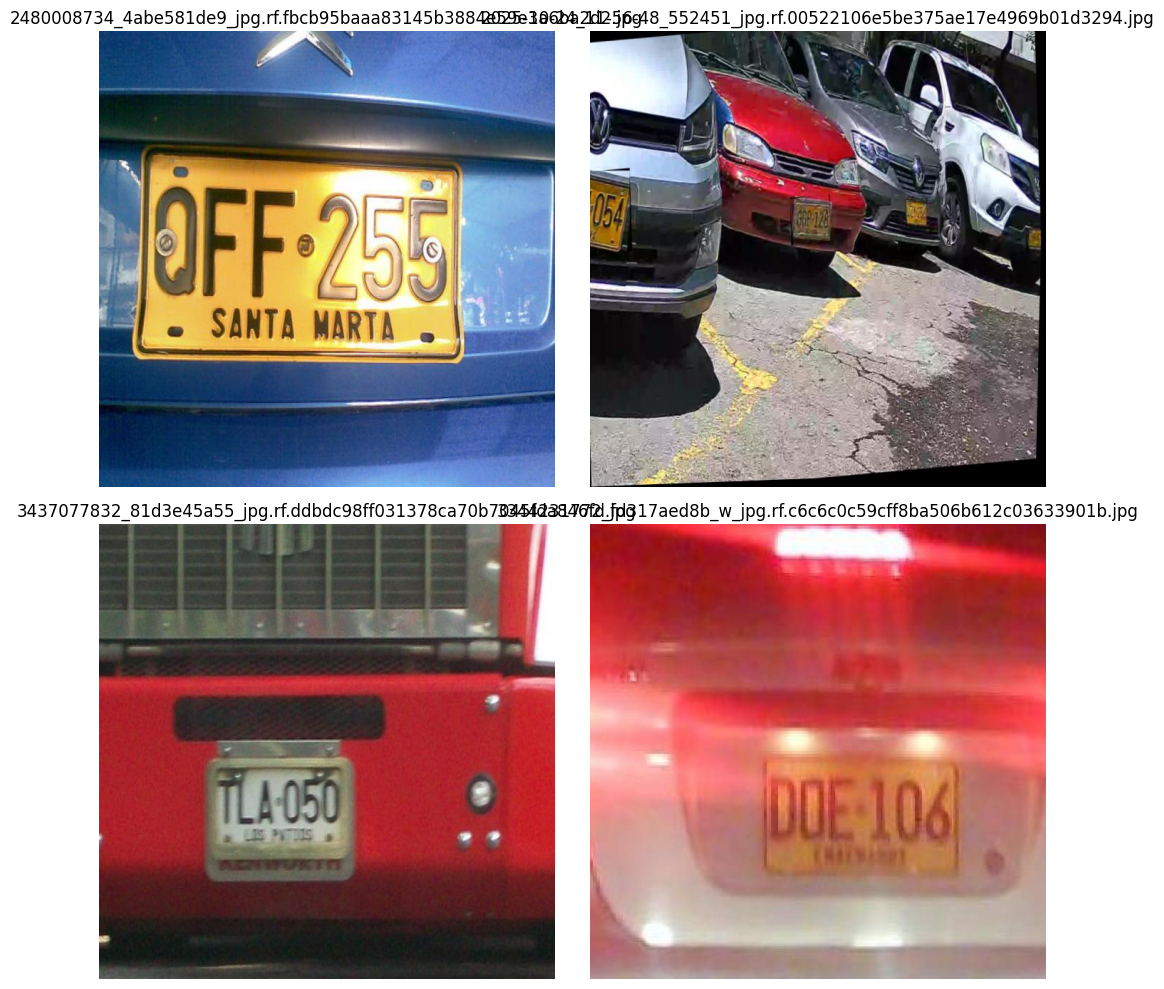

In [7]:
train_images_path = os.path.join(base_dir, 'train', 'images')
all_train_images = [os.path.join(train_images_path, f) for f in os.listdir(train_images_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Seleccionar 4 imágenes aleatorias
np.random.seed(42) # Para reproducibilidad
sample_images_paths = np.random.choice(all_train_images, 4, replace=False)

plt.figure(figsize=(10, 10))
for i, img_path in enumerate(sample_images_paths):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # OpenCV lee en BGR, matplotlib espera RGB
    plt.subplot(2, 2, i + 1) # Crear una cuadrícula de 2x2
    plt.imshow(img)
    plt.title(os.path.basename(img_path))
    plt.axis('off')

plt.tight_layout()
plt.show()

## 🤖 8. Carga del modelo base YOLOv11-Large

Cargamos **YOLO11-Large** preentrenado en el dataset COCO como punto de partida.  
Usaremos *transfer learning* (fine-tuning) para especializarlo en detectar únicamente placas colombianas, aprovechando el conocimiento previo del modelo sobre formas rectangulares y caracteres.


In [8]:
from ultralytics import YOLO

# Cargar YOLO11 Large preentrenado en COCO dataset
# El modelo se descarga automáticamente la primera vez
model = YOLO("yolo11l.pt")

print("✅ Modelo YOLO11-Large cargado correctamente")
print("\n📋 Información del modelo:")
model.info()

✅ Modelo YOLO11-Large cargado correctamente

📋 Información del modelo:
YOLO11l summary: 357 layers, 25,372,160 parameters, 0 gradients, 87.6 GFLOPs


(357, 25372160, 0, 87.6134912)

## 🏋️ 9. Entrenamiento del modelo (Fine-Tuning)

Realizamos el fine-tuning del modelo durante **50 épocas** con las siguientes configuraciones clave:

- `imgsz=640` — Tamaño estándar de entrada para YOLO  
- `batch=16` — Tamaño de batch ajustado a la GPU T4  
- `patience=10` — Early stopping para evitar sobreajuste  
- `device=0` — Entrenamiento en GPU

> ⏱️ El entrenamiento puede tardar entre 20 y 60 minutos dependiendo del tamaño del dataset.


In [9]:
# Entrenamiento del modelo con fine-tuning
results = model.train(
    data=data_yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10,          # Early stopping: para si no mejora en 10 épocas
    name="detector_placas",
    project="/content/proyecto_placas",
    device=0,             # Usar GPU
    verbose=True
)

print("\n✅ Entrenamiento completado")
print(f"📁 Resultados guardados en: /content/proyecto_placas/detector_placas")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/placa-de-carro-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=detector_placas-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True

## ✅ 10. Validación del mejor modelo

Cargamos el mejor checkpoint (`best.pt`) guardado durante el entrenamiento y lo evaluamos sobre el conjunto de validación.  
Las métricas clave para un detector de placas colombianas son:

- **Precision** — ¿Cuántas detecciones son realmente placas?  
- **Recall** — ¿Cuántas placas reales fueron encontradas?  
- **mAP@50** — Precisión media con umbral IoU del 50%


In [19]:
model_path = '/content/proyecto_placas/detector_placas/weights/best.pt'
model_best = YOLO(model_path)

print(f"\n✅ Modelo '{os.path.basename(model_path)}' cargado correctamente para validación")

# Validar el modelo en el conjunto de validación
metrics = model_best.val(data=data_yaml_path)

print("\n📋 Métricas de validación del mejor modelo:")
print(f"  Precision (P): {metrics.results_dict['metrics/precision(B)']: .3f}")
print(f"  Recall (R): {metrics.results_dict['metrics/recall(B)']: .3f}")
print(f"  mAP50: {metrics.results_dict['metrics/mAP50(B)']: .3f}")
print(f"  mAP50-95: {metrics.results_dict['metrics/mAP50-95(B)']: .3f}")


✅ Modelo 'best.pt' cargado correctamente para validación
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11l summary (fused): 191 layers, 25,280,083 parameters, 0 gradients, 86.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1428.7±614.4 MB/s, size: 111.1 KB)
val: Scanning /content/placa-de-carro-1/valid/labels.cache... 220 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 220/220 102.5Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 189, len(boxes) = 220. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 1.2it/s 11.3s
                   all        220        220      0.965      0.993      0.993       0.81
Speed: 2.6ms preprocess, 42.8ms inference, 0.0ms loss, 0.7

## 📊 11. Visualización de métricas de entrenamiento

Graficamos la evolución de las métricas a lo largo de las épocas para analizar la convergencia del modelo:

- **Pérdidas** (train y validación): deben decrecer progresivamente  
- **mAP@50 y mAP@50-95**: deben aumentar y estabilizarse  
- **Precisión y Recall**: balance entre falsos positivos y falsos negativos


📊 Últimas 5 épocas:
 epoch    time  train/box_loss  train/cls_loss  train/dfl_loss  metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss   lr/pg0   lr/pg1   lr/pg2
    46 4656.61         0.62900         0.42142         1.01473               0.97319            0.98989           0.99251              0.79317       0.73783       0.43760       1.08438 0.000218 0.000218 0.000218
    47 4754.52         0.62212         0.41131         1.01157               0.96466            0.99262           0.99268              0.81205       0.68781       0.41255       1.02791 0.000178 0.000178 0.000178
    48 4855.70         0.62748         0.40925         1.01945               0.96887            0.99031           0.99169              0.79840       0.71003       0.43582       1.06286 0.000139 0.000139 0.000139
    49 4955.69         0.60985         0.39364         1.00158               0.98443            0.99091           0.99445           

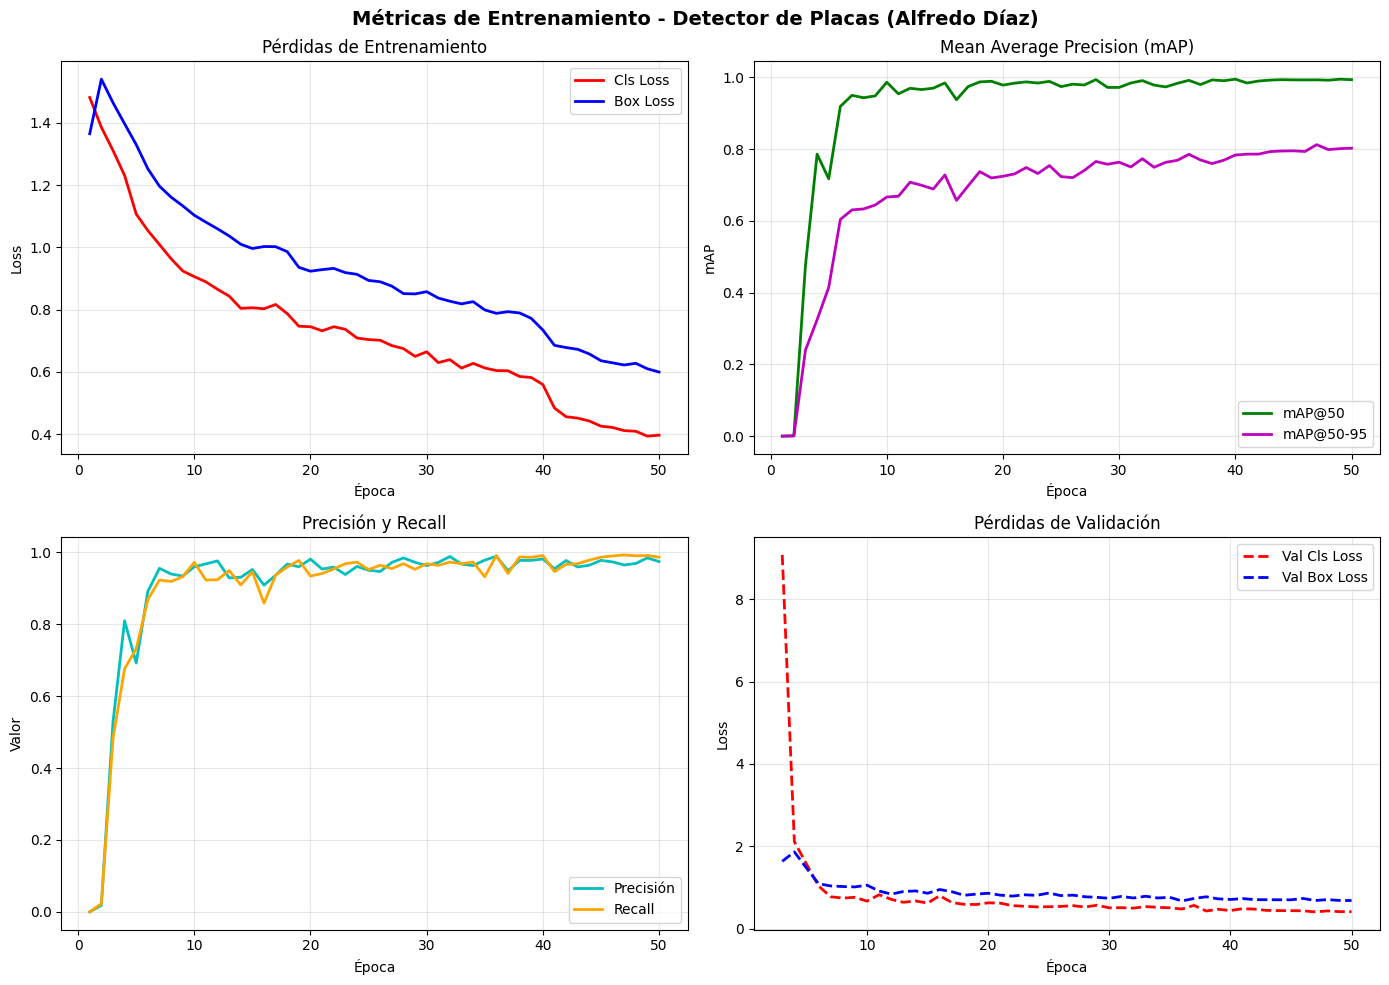


🏆 Mejor época: 40
   mAP@50:     0.9945
   Precisión:  0.9813
   Recall:     0.9909


In [20]:
# Cargar métricas de entrenamiento
results_path = "/content/proyecto_placas/detector_placas/results.csv"
df_metrics = pd.read_csv(results_path)
df_metrics.columns = df_metrics.columns.str.strip()  # Limpiar espacios en nombres

print("📊 Últimas 5 épocas:")
print(df_metrics.tail(5).to_string(index=False))

# Graficar métricas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Métricas de Entrenamiento - Detector de Placas (Alfredo Díaz)',
             fontsize=14, fontweight='bold')

# Pérdidas de entrenamiento
axes[0, 0].plot(df_metrics['epoch'], df_metrics['train/cls_loss'], 'r-', label='Cls Loss', linewidth=2)
axes[0, 0].plot(df_metrics['epoch'], df_metrics['train/box_loss'], 'b-', label='Box Loss', linewidth=2)
axes[0, 0].set_title('Pérdidas de Entrenamiento')
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# mAP
axes[0, 1].plot(df_metrics['epoch'], df_metrics['metrics/mAP50(B)'], 'g-', label='mAP@50', linewidth=2)
axes[0, 1].plot(df_metrics['epoch'], df_metrics['metrics/mAP50-95(B)'], 'm-', label='mAP@50-95', linewidth=2)
axes[0, 1].set_title('Mean Average Precision (mAP)')
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('mAP')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Precisión y Recall
axes[1, 0].plot(df_metrics['epoch'], df_metrics['metrics/precision(B)'], 'c-', label='Precisión', linewidth=2)
axes[1, 0].plot(df_metrics['epoch'], df_metrics['metrics/recall(B)'], 'orange', label='Recall', linewidth=2)
axes[1, 0].set_title('Precisión y Recall')
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('Valor')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Pérdida de validación
axes[1, 1].plot(df_metrics['epoch'], df_metrics['val/cls_loss'], 'r--', label='Val Cls Loss', linewidth=2)
axes[1, 1].plot(df_metrics['epoch'], df_metrics['val/box_loss'], 'b--', label='Val Box Loss', linewidth=2)
axes[1, 1].set_title('Pérdidas de Validación')
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/metricas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()

# Resumen final
mejor_epoch = df_metrics['metrics/mAP50(B)'].idxmax()
print(f"\n🏆 Mejor época: {df_metrics.loc[mejor_epoch, 'epoch']:.0f}")
print(f"   mAP@50:     {df_metrics.loc[mejor_epoch, 'metrics/mAP50(B)']:.4f}")
print(f"   Precisión:  {df_metrics.loc[mejor_epoch, 'metrics/precision(B)']:.4f}")
print(f"   Recall:     {df_metrics.loc[mejor_epoch, 'metrics/recall(B)']:.4f}")

## 🔍 12. Evaluación final sobre conjunto de validación

Segunda evaluación del modelo para confirmar los resultados de forma explícita, reportando métricas directamente desde el objeto de resultados de Ultralytics.


In [21]:
# Cargar el mejor modelo entrenado (best.pt)
ruta_modelo = "/content/proyecto_placas/detector_placas/weights/best.pt"
modelo_entrenado = YOLO(ruta_modelo)

print(f"✅ Modelo cargado desde: {ruta_modelo}")

# Evaluar en el conjunto de validación
print("\n🔍 Evaluando en conjunto de validación...")
eval_results = modelo_entrenado.val(
    data=data_yaml_path,
    split='val'
)

print("\n📊 Resultados de evaluación:")
print(f"   mAP@50:      {eval_results.box.map50:.4f}")
print(f"   mAP@50-95:   {eval_results.box.map:.4f}")
print(f"   Precisión:   {eval_results.box.mp:.4f}")
print(f"   Recall:      {eval_results.box.mr:.4f}")

✅ Modelo cargado desde: /content/proyecto_placas/detector_placas/weights/best.pt

🔍 Evaluando en conjunto de validación...
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11l summary (fused): 191 layers, 25,280,083 parameters, 0 gradients, 86.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1462.2±259.7 MB/s, size: 47.0 KB)
val: Scanning /content/placa-de-carro-1/valid/labels.cache... 220 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 220/220 71.0Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 189, len(boxes) = 220. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 1.3it/s 10.8s
                   all        220        220      0.965      0.993      0.993       

## 📤 13. Exportación del modelo a formato ONNX

Exportamos el modelo entrenado a **ONNX** para facilitar su despliegue en producción.  
ONNX permite usar el modelo en múltiples frameworks y plataformas sin depender de PyTorch, incluyendo la aplicación Streamlit (`app.py`).


In [22]:
# Ruta al mejor modelo entrenado (formato .pt)
model_path = '/content/proyecto_placas/detector_placas/weights/best.pt'

# Cargar el modelo YOLO
# Asegúrate de que `model_best` esté disponible del paso anterior, o cárgalo de nuevo
# Si `model_best` ya está cargado y es el objeto YOLO correcto, esta línea no hará una recarga innecesaria.
# Sin embargo, para asegurar que siempre esté disponible, lo cargamos explícitamente aquí si no existe.
if 'model_best' not in globals() or not isinstance(model_best, YOLO):
    print("Cargando el modelo .pt ya que no está en la memoria.")
    model_best = YOLO(model_path)

print(f"✅ Modelo .pt cargado desde: {model_path}")

# Exportar el modelo a formato ONNX
# imgsz=640 es el tamaño de imagen predeterminado para la inferencia, asegúrate de que coincida con tu entrenamiento
print("⏳ Exportando modelo a formato ONNX...")
onnx_output_path = model_best.export(format='onnx', imgsz=640, simplify=True)

print(f"✅ Modelo ONNX exportado exitosamente a: {onnx_output_path}")

✅ Modelo .pt cargado desde: /content/proyecto_placas/detector_placas/weights/best.pt
⏳ Exportando modelo a formato ONNX...
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/content/proyecto_placas/detector_placas/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (48.8 MB)

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 4.8s, saved as '/content/proyecto_placas/detector_placas/weights/best.onnx' (96.8 MB)

Export complete (7.6s)
Results saved to /content/proyecto_placas/detector_placas/weights
Predict:         yolo predict task=detect model=/content/proyecto_placas/detector_placas/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/proyecto_placas/detector_placas/weights/best.onnx imgsz=640 data=/content/placa-de-carro-1/data.yaml  
Visualize:       https://netron.app
✅ Modelo ONNX exportado ex

## 🔬 14. Prueba del pipeline completo (imagen aleatoria)

Ejecutamos el pipeline completo — detección YOLO + preprocesamiento + OCR — sobre una imagen aleatoria del conjunto de prueba para validar el funcionamiento de extremo a extremo antes de definir la función principal.


In [31]:
import random

# Alias para la función de preprocesamiento, ya que se definió como 'preprocesar_placa'
# pero se llama como 'preprocess_plate' dentro de detect_and_recognize_plate.
# Idealmente, la función detect_and_recognize_plate debería corregirse, pero
# dado el requisito de modificar solo esta celda, esta es una solución temporal.
preprocess_plate = preprocesar_placa

# Seleccionar una imagen aleatoria del conjunto de prueba para la demostración
# Asegúrate de que `test_images_path` y `all_test_images` estén definidos

if 'all_test_images' not in globals() or not all_test_images:
    test_images_path = os.path.join(base_dir, data_yaml['test'].replace('../', ''))
    all_test_images = [os.path.join(test_images_path, f) for f in os.listdir(test_images_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

if all_test_images:
    test_image_for_pipeline = random.choice(all_test_images)
    print(f"\nProcesando imagen de prueba: {test_image_for_pipeline}")

    # Ejecutar el pipeline
    # Usar model_best que ya ha sido cargado y validado
    output_image, plates_data = detect_and_recognize_plate(test_image_for_pipeline, model_best, reader)

    # Mostrar resultados
    if output_image is not None:
        plt.figure(figsize=(12, 8))
        plt.imshow(output_image)
        plt.title('Detección y Reconocimiento de Placas - Pipeline')
        plt.axis('off')
        plt.show()

        print("\n--- Resultados Detallados ---")
        if plates_data:
            for i, plate in enumerate(plates_data):
                print(f"Placa {i+1}:")
                print(f"  BBox: {plate['bbox']}")
                print(f"  Confianza: {plate['confidence']:.2f}")
                print(f"  Texto OCR en crudo: {plate['raw_ocr_text']}")
                print(f"  Placa Formateada: {plate['formatted_plate']}")
                print(f"  Letras: {plate['letters']}")
                print(f"  Números: {plate['numbers']}")
        else:
            print("No se detectaron placas en la imagen.")
    else:
        print("No se pudo procesar la imagen para el pipeline.")
else:
    print("No hay imágenes de prueba disponibles para ejecutar el pipeline.")

⏳ Inicializando EasyOCR (puede tardar unos segundos)...
✅ EasyOCR inicializado
✅ Funciones de procesamiento definidas


## 🧩 15. Función principal: `detect_and_recognize_plate()`

Definimos el pipeline completo de detección y reconocimiento encapsulado en una función reutilizable:

1. **Carga la imagen** con OpenCV  
2. **Detecta placas** con el modelo YOLO entrenado (bounding boxes)  
3. **Preprocesa el recorte** de la placa (escala de grises, CLAHE, filtro bilateral)  
4. **Aplica EasyOCR** para extraer caracteres alfanuméricos  
5. **Formatea el resultado** al estándar colombiano **ABC-123**  
6. **Dibuja** las anotaciones sobre la imagen de salida


In [32]:
def detect_and_recognize_plate(image_path, model_detector, ocr_reader, conf_threshold=0.25, iou_threshold=0.7):
    """
    Pipeline completo para detectar placas y reconocer su texto en una imagen.

    Args:
        image_path (str): Ruta a la imagen de entrada.
        model_detector (YOLO): Modelo YOLO entrenado para detección de placas.
        ocr_reader (easyocr.Reader): Objeto EasyOCR inicializado.
        conf_threshold (float): Umbral de confianza para las detecciones de YOLO.
        iou_threshold (float): Umbral de IOU para las detecciones de YOLO.

    Returns:
        tuple: (processed_image, detected_plates_info)
            processed_image (np.array): Imagen con las detecciones y textos dibujados.
            detected_plates_info (list): Lista de diccionarios con información de cada placa detectada.
    """
    original_img = cv2.imread(image_path)
    if original_img is None:
        print(f"Error: No se pudo cargar la imagen de la ruta: {image_path}")
        return None, []

    # Crear una copia de la imagen para dibujar las detecciones
    display_img = original_img.copy()
    display_img_rgb = cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB)
    h_orig, w_orig, _ = original_img.shape

    detected_plates_info = []

    # 1. Detección de placas con YOLO
    results = model_detector.predict(source=image_path, conf=conf_threshold, iou=iou_threshold, show=False, save=False, verbose=False)

    if results and len(results[0].boxes) > 0:
        for detection in results[0].boxes:
            bbox_xyxy = detection.xyxy[0].cpu().numpy().astype(int) # [x1, y1, x2, y2]
            confidence = detection.conf[0].cpu().numpy()

            x1, y1, x2, y2 = bbox_xyxy

            # Asegurarse de que las coordenadas estén dentro de los límites de la imagen
            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(w_orig, x2)
            y2 = min(h_orig, y2)

            if x2 <= x1 or y2 <= y1:
                print("Advertencia: Bounding box inválido o muy pequeño, saltando detección.")
                continue

            # 2. Preprocesamiento de la placa detectada
            preprocessed_plate_img = preprocess_plate(original_img, [x1, y1, x2, y2])

            recognized_text = "N/A"
            formatted_plate = "N/A"
            plate_letters = "N/A"
            plate_numbers = "N/A"

            if preprocessed_plate_img is not None:
                # 3. Reconocimiento de texto con EasyOCR
                # Especificar `allowlist` si se conoce el tipo de caracteres esperados (letras y números)
                # O `detail=0` para obtener solo el texto
                ocr_results = ocr_reader.readtext(preprocessed_plate_img, detail=0, allowlist='ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-')

                if ocr_results:
                    # Unir todos los textos reconocidos de la placa
                    full_text = "".join(ocr_results)

                    # 4. Extracción y formato del número de placa
                    formatted_plate, plate_letters, plate_numbers, _ = extraer_ciudad_placa(full_text)
                    recognized_text = formatted_plate if formatted_plate else full_text
                else:
                    recognized_text = "No text found"
            else:
                recognized_text = "Preprocessing failed"

            # Almacenar información de la placa
            detected_plates_info.append({
                'bbox': bbox_xyxy,
                'confidence': float(confidence),
                'raw_ocr_text': full_text if 'full_text' in locals() else "",
                'formatted_plate': recognized_text,
                'letters': plate_letters,
                'numbers': plate_numbers
            })

            # 5. Visualizar los resultados en la imagen
            cv2.rectangle(display_img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2) # BBox verde
            cv2.putText(display_img_rgb, f"{recognized_text} ({confidence:.2f})", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    return display_img_rgb, detected_plates_info

print("✅ Pipeline de detección y reconocimiento de placas definido.")

✅ Pipeline de detección y reconocimiento de placas definido.


## 🚀 16. Demostración final del pipeline

Corremos la función `detect_and_recognize_plate()` sobre una imagen aleatoria del conjunto de prueba y mostramos:

- La imagen anotada con el bounding box y el texto reconocido  
- Los detalles de cada placa: coordenadas, confianza, texto crudo OCR y placa formateada en formato **ABC-123**



Procesando imagen de prueba: /content/placa-de-carro-1/test/images/3680411248_7136508a7d_m_jpg.rf.ccfd71851459943f4dcdbb697bced939.jpg


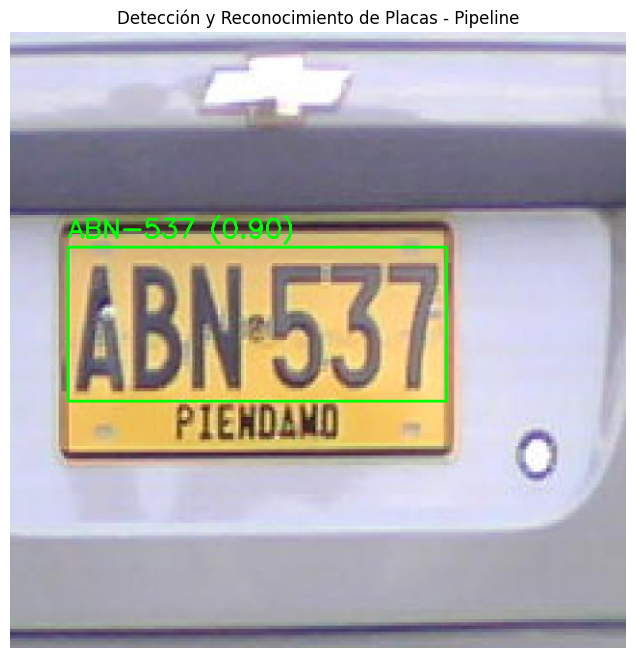


--- Resultados Detallados ---
Placa 1:
  BBox: [ 60 223 453 383]
  Confianza: 0.90
  Texto OCR en crudo: ABN537
  Placa Formateada: ABN-537
  Letras: ABN
  Números: 537


In [38]:
import random

# Alias para la función de preprocesamiento, ya que se definió como 'preprocesar_placa'
# pero se llama como 'preprocess_plate' dentro de detect_and_recognize_plate.
# Idealmente, la función detect_and_recognize_plate debería corregirse, pero
# dado el requisito de modificar solo esta celda, esta es una solución temporal.
preprocess_plate = preprocesar_placa

# Seleccionar una imagen aleatoria del conjunto de prueba para la demostración
# Asegúrate de que `test_images_path` y `all_test_images` estén definidos

if 'all_test_images' not in globals() or not all_test_images:
    test_images_path = os.path.join(base_dir, data_yaml['test'].replace('../', ''))
    all_test_images = [os.path.join(test_images_path, f) for f in os.listdir(test_images_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

if all_test_images:
    test_image_for_pipeline = random.choice(all_test_images)
    print(f"\nProcesando imagen de prueba: {test_image_for_pipeline}")

    # Ejecutar el pipeline
    # Usar model_best que ya ha sido cargado y validado
    output_image, plates_data = detect_and_recognize_plate(test_image_for_pipeline, model_best, reader)

    # Mostrar resultados
    if output_image is not None:
        plt.figure(figsize=(12, 8))
        plt.imshow(output_image)
        plt.title('Detección y Reconocimiento de Placas - Pipeline')
        plt.axis('off')
        plt.show()

        print("\n--- Resultados Detallados ---")
        if plates_data:
            for i, plate in enumerate(plates_data):
                print(f"Placa {i+1}:")
                print(f"  BBox: {plate['bbox']}")
                print(f"  Confianza: {plate['confidence']:.2f}")
                print(f"  Texto OCR en crudo: {plate['raw_ocr_text']}")
                print(f"  Placa Formateada: {plate['formatted_plate']}")
                print(f"  Letras: {plate['letters']}")
                print(f"  Números: {plate['numbers']}")
        else:
            print("No se detectaron placas en la imagen.")
    else:
        print("No se pudo procesar la imagen para el pipeline.")
else:
    print("No hay imágenes de prueba disponibles para ejecutar el pipeline.")